# Churn Prediction Model

Goal: predict which loyalty members are likely to churn (as defined in
Feature_Engineering), using only the features available before the
label window.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [43]:
final_dataset = pd.read_csv('Final_dataset.csv')
print(final_dataset.shape)
final_dataset.head(3)

(13699, 32)


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Total Flights in Lifetime,Total Distance,Net Reward Points,Redeem Ratio,Months Since Last Flight,Flights in last 3 months,Flights in last 6 months,Engagement Score,Cancelled In Label Window,Churn
0,480934,canada,ontario,toronto,m2z 4k1,female,bachelor,83236.0,married,star,...,24,31092,30770.0,0.01,1,6,6,0.162575,False,0
1,549612,canada,alberta,edmonton,t3g 6y6,male,college,73455.0,divorced,star,...,45,56299,55159.0,0.02,0,11,14,0.225587,False,0
2,608370,canada,ontario,toronto,p1w 1k4,male,college,73455.0,single,star,...,30,42154,41290.0,0.02,0,3,6,0.267894,False,0


## 1. Feature list

Same `non_feature_cols` exclusion we already built and leakage-checked in
`Feature_Engineering

In [44]:
non_feature_cols = [
    'Loyalty Number', 'Cancellation Year', 'Cancellation Month', 'Cancellation Date',
    'Cancelled In Label Window', 'Cancelled Before Cutoff', 'Enrolled After Cutoff',
    'Churn',
    'Country',
    'Postal Code',
    'Enrollment Date'
    # the last three are not sources of leakage but they are not useful for modelling
]
feature_cols = [c for c in final_dataset.columns if c not in non_feature_cols]

print('Modelling features:')
for c in feature_cols:
    print(' -', c)

Modelling features:
 - Province
 - City
 - Gender
 - Education
 - Salary
 - Marital Status
 - Loyalty Card
 - CLV
 - Enrollment Type
 - Enrollment Year
 - Enrollment Month
 - Promotion Customer
 - Tenure
 - Total Flights in Lifetime
 - Total Distance
 - Net Reward Points
 - Redeem Ratio
 - Months Since Last Flight
 - Flights in last 3 months
 - Flights in last 6 months
 - Engagement Score


## 2. Encoding categorical columns


In [45]:
categorical_cols = ['Province', 'City', 'Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type']

data_for_model = final_dataset[feature_cols].copy()
data_for_model = pd.get_dummies(data_for_model, columns=categorical_cols, drop_first=True)

X = data_for_model
y = final_dataset['Churn']

print('X shape:', X.shape)
print('Churn rate:', round(y.mean() * 100, 2), '%')

X shape: (13699, 62)
Churn rate: 5.56 %


## 3. Train / test split


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
) # Re-running train/test split to update X_train and X_test

print('Train set:', X_train.shape[0], 'members')
print('Test set: ', X_test.shape[0], 'members')

Train set: 10274 members
Test set:  3425 members


## 4. Train the model

Random Forest Classifier is used here as it is Easy to explain to a non-technical audience and its feature
importances are directly interpretable, which matters for the strategy memo.


In [47]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
)
# Re-fitting the model now that 'Enrollment Date' string column is excluded
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       random_state=42)

## 5. Evaluate on the test set

In [48]:
y_pred = model.predict(X_test)

print('Accuracy: ', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3),
      ' (of members we flagged as churn risk, how many actually churned)')
print('Recall:   ', round(recall_score(y_test, y_pred), 3),
      ' (of members who actually churned, how many did we catch)')
print('F1 score: ', round(f1_score(y_test, y_pred), 3))

Accuracy:  0.909
Precision: 0.328  (of members we flagged as churn risk, how many actually churned)
Recall:    0.6  (of members who actually churned, how many did we catch)
F1 score:  0.424


In [49]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Active', 'Actual: Churned'],
    columns=['Predicted: Active', 'Predicted: Churned']
)
print('Confusion matrix:')
cm_df

Confusion matrix:


,Predicted: Active,Predicted: Churned
Actual: Active,3001,234
Actual: Churned,76,114


In [50]:
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

              precision    recall  f1-score   support

      Active       0.98      0.93      0.95      3235
     Churned       0.33      0.60      0.42       190

    accuracy                           0.91      3425
   macro avg       0.65      0.76      0.69      3425
weighted avg       0.94      0.91      0.92      3425



## 6. Which behaviours matter most?


In [51]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
12,Flights in last 6 months,0.143672
7,Total Distance,0.122340
6,Total Flights in Lifetime,0.096129
10,Months Since Last Flight,0.096106
8,Net Reward Points,0.093573
11,Flights in last 3 months,0.076311
5,Tenure,0.073873
9,Redeem Ratio,0.045321
13,Engagement Score,0.042643
2,Enrollment Year,0.041894


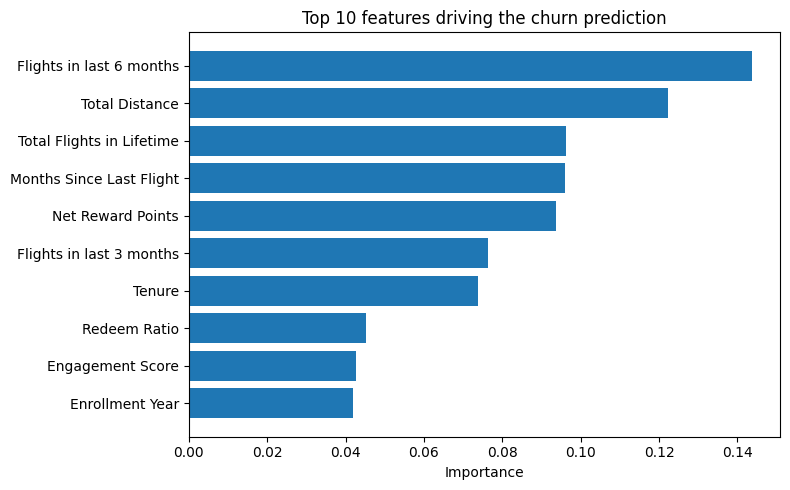

In [52]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 10 features driving the churn prediction')
plt.tight_layout()
plt.show()

## 7. Score every member (not just the test set)

The test set was for evaluating the model honestly. Now that we trust it,
we score every eligible member so we have a churn risk score to hand to
the segmentation step and the retention playbook.

In [53]:
final_dataset['churn_risk_score'] = model.predict_proba(X)[:, 1]

def risk_bucket(score):
    if score >= 0.6:
        return 'High Risk'
    elif score >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

final_dataset['churn_risk_tier'] = final_dataset['churn_risk_score'].apply(risk_bucket)

print(final_dataset['churn_risk_tier'].value_counts())

churn_risk_tier
Low Risk       10915
Medium Risk     2061
High Risk        723
Name: count, dtype: int64


In [54]:
final_dataset.to_csv('customer_churn_scored.csv', index=False)
files.download('customer_churn_scored.csv')
print('Saved customer_churn_scored.csv with', final_dataset.shape[0], 'rows')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved customer_churn_scored.csv with 13699 rows
